## Definição e carregamento de bases de dados para Matching

Para a estimação de um grupo de controle comparável a Florianópolis, optou-se por escolher as seguintes covariáveis para a estimação do matching.
-> Variáveis escolhidas e suas fontes:  
 * PIB per Capita (IBGE)
 * População (IBGE)
 * Participação do setor de serviços no PIB (IBGE)
 * Educação média (RAIS)

 Variáveis mapeadas com possível introdução em uma nova versão
 * Taxa de desemprego (PNAD)
 * Variável de infraestrutura (energia elétrica ou saneamento básico, por exemplo)

 Obs: todos as base de dados são carregadas diretamente do repositório no github. No caso da RAIS, se desejar alterar os parâmetros de busca no database, o código está como comentário.


## Importação das bibliotecas utilizadas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sidrapy
import basedosdados as bd
import numpy as np
import math
from scipy.stats import zscore
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


## Carregamento de dados via SIDRA
* PIB per Capita
* População
* Participação do setor de serviços

In [2]:
df_pib_per_capita = pd.read_csv("https://github.com/mvtp23/TCC/releases/download/database_ibge/pib_per_capita_municipios_2003_2023.csv",sep=',', encoding='utf-8-sig')

In [3]:
df_pib_per_capita

,cod_municipio,ano,pib_per_capita,nome_municipio,sigla_uf
0,1100015,2003,143222.0,Alta Floresta D'Oeste,RO
1,1100023,2003,539636.0,Ariquemes,RO
2,1100031,2003,40985.0,Cabixi,RO
3,1100049,2003,622437.0,Cacoal,RO
4,1100056,2003,99983.0,Cerejeiras,RO
...,...,...,...,...,...
116901,5222005,2023,914943.0,Vianópolis,GO
116902,5222054,2023,677600.0,Vicentinópolis,GO
116903,5222203,2023,201846.0,Vila Boa,GO
116904,5222302,2023,444209.0,Vila Propício,GO


In [4]:
df_populacao = pd.read_csv("https://github.com/mvtp23/TCC/releases/download/database_ibge/populacao_municipios_2003_2023.csv",sep=',', encoding='utf-8-sig')

In [5]:
df_populacao.tail()

,cod_municipio,ano,populacao,nome_municipio,sigla_uf
94642,5222005,2021,14088.0,Vianópolis,GO
94643,5222054,2021,9002.0,Vicentinópolis,GO
94644,5222203,2021,6451.0,Vila Boa,GO
94645,5222302,2021,5941.0,Vila Propício,GO
94646,5300108,2021,3094325.0,Brasília,DF


In [6]:
df_pib_setor = pd.read_csv("https://github.com/mvtp23/TCC/releases/download/database_ibge/pib_setorial_municipios_2010_2021.csv",sep=',', encoding='utf-8-sig')

In [7]:
df_pib_setor[df_pib_setor["ano"]==2021]

,cod_municipio,nome_municipio,sigla_uf,ano,pib_total,part_agropecuaria,part_industria,part_servicos,part_adm_publica
100260,1100015,Alta Floresta D'Oeste,RO,2021,734467.0,45.48,4.07,25.18,25.28
100261,1100023,Ariquemes,RO,2021,3211294.0,10.50,14.61,46.86,28.03
100262,1100031,Cabixi,RO,2021,238414.0,60.14,3.57,15.78,20.50
100263,1100049,Cacoal,RO,2021,2792506.0,14.17,9.83,49.86,26.13
100264,1100056,Cerejeiras,RO,2021,743062.0,24.82,4.49,50.51,20.19
...,...,...,...,...,...,...,...,...,...
105825,5222005,Vianópolis,GO,2021,858016.0,52.51,5.54,32.38,9.57
105826,5222054,Vicentinópolis,GO,2021,480210.0,43.42,19.55,25.28,11.75
105827,5222203,Vila Boa,GO,2021,179924.0,35.25,18.27,24.32,22.16
105828,5222302,Vila Propício,GO,2021,308035.0,53.51,19.43,15.83,11.23


In [8]:
df_ibge = pd.merge(df_pib_per_capita, df_populacao, on=['cod_municipio', 'ano', 'sigla_uf',"nome_municipio"], how='inner')
df_ibge = pd.merge(df_ibge, df_pib_setor, on = ["cod_municipio", "ano", "sigla_uf", "nome_municipio"], how='inner')


In [9]:
df_ibge = df_ibge[["ano", "cod_municipio", "nome_municipio", "sigla_uf", "pib_per_capita", "populacao", "part_servicos"]]
df_ibge

,ano,cod_municipio,nome_municipio,sigla_uf,pib_per_capita,populacao,part_servicos
0,2003,1100015,Alta Floresta D'Oeste,RO,143222.0,27563.0,24.85
1,2003,1100023,Ariquemes,RO,539636.0,79680.0,41.40
2,2003,1100031,Cabixi,RO,40985.0,7478.0,16.39
3,2003,1100049,Cacoal,RO,622437.0,74758.0,45.46
4,2003,1100056,Cerejeiras,RO,99983.0,17794.0,39.46
...,...,...,...,...,...,...,...
94632,2021,5222005,Vianópolis,GO,858016.0,14088.0,32.38
94633,2021,5222054,Vicentinópolis,GO,480210.0,9002.0,25.28
94634,2021,5222203,Vila Boa,GO,179924.0,6451.0,24.32
94635,2021,5222302,Vila Propício,GO,308035.0,5941.0,15.83


In [10]:
# Log sobre as variáveis

df_ibge['log_pib_per_capita'] = np.log(df_ibge['pib_per_capita'])
df_ibge['log_populacao'] = np.log(df_ibge['populacao'])

df_ibge = df_ibge.drop(columns=["pib_per_capita","populacao"])

df_ibge

,ano,cod_municipio,nome_municipio,sigla_uf,part_servicos,log_pib_per_capita,log_populacao
0,2003,1100015,Alta Floresta D'Oeste,RO,24.85,11.872151,10.224230
1,2003,1100023,Ariquemes,RO,41.40,13.198650,11.285774
2,2003,1100031,Cabixi,RO,16.39,10.620961,8.919721
3,2003,1100049,Cacoal,RO,45.46,13.341398,11.222012
4,2003,1100056,Cerejeiras,RO,39.46,11.512755,9.786617
...,...,...,...,...,...,...,...
94632,2021,5222005,Vianópolis,GO,32.38,13.662378,9.553079
94633,2021,5222054,Vicentinópolis,GO,25.28,13.081979,9.105202
94634,2021,5222203,Vila Boa,GO,24.32,12.100290,8.771990
94635,2021,5222302,Vila Propício,GO,15.83,12.637969,8.689633


## Carregamento de dados RAIS

* Escolaridade média por município

In [11]:
#id_projeto = "prop-459900"

In [12]:
#dicionario_rais = "SELECT * FROM `basedosdados.br_me_rais.dicionario`"

In [13]:
#dicionario_rais= bd.read_sql(query=dicionario_rais, billing_project_id=id_projeto)

In [14]:
#dicionario_rais.to_parquet("dicionario_rais.parquet")

In [15]:
dicionario_rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/dicionario_rais.parquet")

In [16]:
"""
query_rais = 
SELECT
    ano,
    id_municipio,
    sigla_uf,
    AVG(valor_remuneracao_media) AS media_remuneracao,
    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE ano BETWEEN 2014 AND 2024
AND vinculo_ativo_3112 = '1'
AND valor_remuneracao_media IS NOT NULL
GROUP BY ano, id_municipio, sigla_uf
"""


"\nquery_rais = \nSELECT\n    ano,\n    id_municipio,\n    sigla_uf,\n    AVG(valor_remuneracao_media) AS media_remuneracao,\n    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao\nFROM `basedosdados.br_me_rais.microdados_vinculos`\nWHERE ano BETWEEN 2014 AND 2024\nAND vinculo_ativo_3112 = '1'\nAND valor_remuneracao_media IS NOT NULL\nGROUP BY ano, id_municipio, sigla_uf\n"

In [17]:
#rais = bd.read_sql(query=query_rais, billing_project_id=id_projeto)

In [18]:
rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/rais.parquet")

In [19]:
rais.head(10)

,ano,id_municipio,sigla_uf,media_remuneracao,media_grau_instrucao
0,2014,1200385,AC,1298.782420,6.380491
1,2015,1600204,AP,1526.431580,6.520833
2,2018,5300108,DF,5205.375480,7.309029
3,2015,1200450,AC,1482.683027,6.346425
4,2015,1200302,AC,1414.295658,5.937701
5,2017,5300108,DF,4985.813913,7.173146
6,2022,1200104,AC,2369.228676,6.932105
7,2020,1400100,RR,3355.947724,7.497132
8,2015,1400605,RR,1194.314525,7.094923
9,2015,1400159,RR,1484.684438,6.764706


In [20]:
rais["id_municipio"] = pd.to_numeric(rais["id_municipio"], errors="coerce")

In [21]:
codigos_municipios = pd.read_excel("https://github.com/mvtp23/TCC/releases/download/database_ibge/Codigos.Municipios.IBGE.xlsx", header=1)
codigos_municipios = codigos_municipios[["Nome_Município","Código Município Completo"]]


Tradução dos dados RAIS através de dicionário de dados

In [22]:
# Criação do mapa para faixa_etaria
mapa_faixa_etaria = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'faixa_etaria']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

# Criação do mapa para sexo
mapa_sexo = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'sexo']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


mapa_subsetor_ibge = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'subsetor_ibge']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

mapa_grau_instrucao = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'grau_instrucao_apos_2005']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


In [23]:
rais_tratada = rais.copy()
rais_tratada.sort_values(by=['ano'], inplace=True)


In [24]:
rais_tratada['log_escolaridade'] = np.log(rais_tratada['media_grau_instrucao'])
rais_tratada = rais_tratada[["ano", "id_municipio", "sigla_uf", "log_escolaridade"]]


In [25]:

# Create a dictionary from codigos_municipios to map Código Município Completo to Nome_Município
mapa_municipios_nomes = codigos_municipios.set_index('Código Município Completo')['Nome_Município'].to_dict()

# Map the 'id_municipio' in rais_tratada to the municipality names
rais_tratada['municipio_trabalho'] = rais_tratada['id_municipio'].map(mapa_municipios_nomes)

# Display the first few rows with the new column
display(rais_tratada)

,ano,id_municipio,sigla_uf,log_escolaridade,municipio_trabalho
50112,2014,4202131.0,SC,1.920923,Bela Vista do Toldo
50107,2014,4202875.0,SC,1.656426,Brunópolis
50106,2014,4217550.0,SC,1.837412,Serra Alta
50105,2014,4218251.0,SC,1.761184,Timbó Grande
38981,2014,4127858.0,PR,1.868349,Três Barras do Paraná
...,...,...,...,...,...
61260,2024,1715705.0,TO,1.902565,Palmeirante
61268,2024,1720259.0,TO,1.966441,São Salvador do Tocantins
148,2024,1400506.0,RR,1.829984,São João da Baliza
22,2024,1400407.0,RR,2.013812,Normandia


## União dos dataframes

In [26]:
df_ibge.head()

,ano,cod_municipio,nome_municipio,sigla_uf,part_servicos,log_pib_per_capita,log_populacao
0,2003,1100015,Alta Floresta D'Oeste,RO,24.85,11.872151,10.224230
1,2003,1100023,Ariquemes,RO,41.40,13.198650,11.285774
2,2003,1100031,Cabixi,RO,16.39,10.620961,8.919721
3,2003,1100049,Cacoal,RO,45.46,13.341398,11.222012
4,2003,1100056,Cerejeiras,RO,39.46,11.512755,9.786617


In [27]:
# Exemplo com inner join
df_combinado = pd.merge(
    rais_tratada,
    df_ibge,
    left_on=['ano', 'id_municipio'],
    right_on=['ano', 'cod_municipio'],
    how='inner',
    suffixes=('_rais', '_ibge')
)

# Remover colunas duplicadas desnecessárias
df_combinado.drop(columns=['Ano', 'Cód.'], inplace=True, errors='ignore')

print(df_combinado.shape)
df_combinado.head()

(44559, 11)


,ano,id_municipio,sigla_uf_rais,log_escolaridade,municipio_trabalho,cod_municipio,nome_municipio,sigla_uf_ibge,part_servicos,log_pib_per_capita,log_populacao
0,2014,4202131.0,SC,1.920923,Bela Vista do Toldo,4202131,Bela Vista do Toldo,SC,16.55,11.833580,8.735364
1,2014,4202875.0,SC,1.656426,Brunópolis,4202875,Brunópolis,SC,25.42,11.007436,7.897296
2,2014,4217550.0,SC,1.837412,Serra Alta,4217550,Serra Alta,SC,29.66,11.397919,8.106816
3,2014,4218251.0,SC,1.761184,Timbó Grande,4218251,Timbó Grande,SC,19.35,11.961674,8.931023
4,2014,4127858.0,PR,1.868349,Três Barras do Paraná,4127858,Três Barras do Paraná,PR,25.86,12.426705,9.410174


In [28]:
df_combinado.columns

Index(['ano', 'id_municipio', 'sigla_uf_rais', 'log_escolaridade',
       'municipio_trabalho', 'cod_municipio', 'nome_municipio',
       'sigla_uf_ibge', 'part_servicos', 'log_pib_per_capita',
       'log_populacao'],
      dtype='object')

In [29]:
df_combinado = df_combinado[["ano", "sigla_uf_ibge", "id_municipio",  "municipio_trabalho",  "log_pib_per_capita", "log_populacao","log_escolaridade", "part_servicos"]]
df_combinado.rename(columns={"municipio_trabalho": "municipio"}, inplace=True)

In [30]:
df_combinado

,ano,sigla_uf_ibge,id_municipio,municipio,log_pib_per_capita,log_populacao,log_escolaridade,part_servicos
0,2014,SC,4202131.0,Bela Vista do Toldo,11.833580,8.735364,1.920923,16.55
1,2014,SC,4202875.0,Brunópolis,11.007436,7.897296,1.656426,25.42
2,2014,SC,4217550.0,Serra Alta,11.397919,8.106816,1.837412,29.66
3,2014,SC,4218251.0,Timbó Grande,11.961674,8.931023,1.761184,19.35
4,2014,PR,4127858.0,Três Barras do Paraná,12.426705,9.410174,1.868349,25.86
...,...,...,...,...,...,...,...,...
44554,2021,AP,1600303.0,Macapá,16.375686,13.166107,2.052147,48.04
44555,2021,TO,1700251.0,Abreulândia,11.627459,7.866722,1.888268,8.76
44556,2021,AP,1600204.0,Calçoene,12.138072,9.349493,1.820470,21.49
44557,2021,RR,1400209.0,Caracaraí,13.024305,10.027253,1.936368,20.68


## Dados ANAC

Leitura da base de dados da ANAC disponível em: https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/

In [31]:
df_anac = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database/dados_anac.parquet")

In [32]:
df_anac

,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_UF,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,...,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,CARGA_PAGA_KM,CARGA_GRATIS_KM,CORREIO_KM,ASSENTOS,PAYLOAD,HORAS_VOADAS,BAGAGEM_KG
0,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
1,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KDFW,"DALLAS & FORT WORTH, TEXAS",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,247320.0,30.0,8.068897e+08,0.0,601812.0,6330.0,1050000.0,"409,08",NaN
2,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,224141.0,29.0,3.715021e+08,0.0,62094786.0,6119.0,464000.0,"418,1",NaN
3,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,222256.0,29.0,1.494457e+09,0.0,15174720.0,6119.0,1015000.0,"411,5",NaN
4,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KMIA,"MIAMI, FLORIDA",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077232,USY,USC GMBH,ESTRANGEIRA,2026,1,MTCH,CAP-HAÏTIEN,None,None,HAITI,...,0.0,7144.0,2.0,0.000000e+00,0.0,0.0,408.0,34000.0,"9,667",0.0
1077233,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2766.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,333",0.0
1077234,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2812.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,4,0.0
1077235,USY,USC GMBH,ESTRANGEIRA,2026,1,SPJC,"CALLAO/LIMA, LIMA METROPOLITAN AREA",None,None,PERU,...,0.0,3572.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,833",0.0


In [33]:
df_anac.columns

Index(['EMPRESA_SIGLA', 'EMPRESA_NOME', 'EMPRESA_NACIONALIDADE', 'ANO', 'MES',
       'AEROPORTO_DE_ORIGEM_SIGLA', 'AEROPORTO_DE_ORIGEM_NOME',
       'AEROPORTO_DE_ORIGEM_UF', 'AEROPORTO_DE_ORIGEM_REGIAO',
       'AEROPORTO_DE_ORIGEM_PAIS', 'AEROPORTO_DE_ORIGEM_CONTINENTE',
       'AEROPORTO_DE_DESTINO_SIGLA', 'AEROPORTO_DE_DESTINO_NOME',
       'AEROPORTO_DE_DESTINO_UF', 'AEROPORTO_DE_DESTINO_REGIAO',
       'AEROPORTO_DE_DESTINO_PAIS', 'AEROPORTO_DE_DESTINO_CONTINENTE',
       'NATUREZA', 'GRUPO_DE_VOO', 'PASSAGEIROS_PAGOS', 'PASSAGEIROS_GRATIS',
       'CARGA_PAGA_KG', 'CARGA_GRATIS_KG', 'CORREIO_KG', 'ASK', 'RPK', 'ATK',
       'RTK', 'COMBUSTIVEL_LITROS', 'DISTANCIA_VOADA_KM', 'DECOLAGENS',
       'CARGA_PAGA_KM', 'CARGA_GRATIS_KM', 'CORREIO_KM', 'ASSENTOS', 'PAYLOAD',
       'HORAS_VOADAS', 'BAGAGEM_KG'],
      dtype='object')

In [34]:
df_anac["PASSAGEIROS_GRATIS"].fillna(0, inplace=True)
df_anac["PASSAGEIROS_PAGOS"].fillna(0, inplace=True)

In [35]:
df_anac["PASSAGEIROS_TOTAL"] = df_anac["PASSAGEIROS_PAGOS"] + df_anac["PASSAGEIROS_GRATIS"]

In [36]:
df_anac[["AEROPORTO_DE_ORIGEM_NOME", "AEROPORTO_DE_ORIGEM_SIGLA"]].drop_duplicates()

,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_SIGLA
0,None,None
1,"DALLAS & FORT WORTH, TEXAS",KDFW
2,"NEW YORK, NEW YORK",KJFK
4,"MIAMI, FLORIDA",KMIA
9,CONFINS,SBCF
...,...,...
1063522,ORAN,DAOO
1063789,"RIVERSIDE, CALIFORNIA",KRIV
1063948,"GUANTÁNAMO BAY, GUANTÁNAMO",MUGM
1069452,HYDERABAD,VOHY


In [37]:
df_anac["PASSAGEIROS_TOTAL"]        

0           161.0
1          4074.0
2          2469.0
3          3019.0
4          1017.0
            ...  
1077232     109.0
1077233       0.0
1077234       0.0
1077235       0.0
1077236      57.0
Name: PASSAGEIROS_TOTAL, Length: 1077237, dtype: float64

In [38]:
# Cria um DataFrame com os dados de origem (passageiros embarcados)
df_origem = df_anac[[
    "ANO",
    "AEROPORTO_DE_ORIGEM_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME",
    "AEROPORTO_DE_ORIGEM_UF",          # sigla da UF  
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_ORIGEM_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_ORIGEM_UF": "UF"
})

# Cria um DataFrame com os dados de destino (passageiros desembarcados)
df_destino = df_anac[[
    "ANO",
    "AEROPORTO_DE_DESTINO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME",
    "AEROPORTO_DE_DESTINO_UF",
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_DESTINO_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_DESTINO_UF": "UF"
})

# Concatena os dois DataFrames
df_combined = pd.concat([df_origem, df_destino], ignore_index=True)

# Agrupa por ano, aeroporto (sigla e nome), UF e Estado, somando os passageiros
df_total_por_aeroporto = df_combined.groupby(
    ["ANO", "AEROPORTO_SIGLA", "AEROPORTO_NOME", "UF"],
    as_index=False
)["PASSAGEIROS_TOTAL"].sum()

# Ordena para melhor visualização
df_total_por_aeroporto = df_total_por_aeroporto.sort_values(
    ["ANO", "PASSAGEIROS_TOTAL"], ascending=[True, False]
)

# Exibe o resultado
print(df_total_por_aeroporto)

       ANO AEROPORTO_SIGLA  AEROPORTO_NOME  UF  PASSAGEIROS_TOTAL
44    2000            SBGR       GUARULHOS  SP         11917074.0
103   2000            SBSP       SÃO PAULO  SP         10588995.0
41    2000            SBGL  RIO DE JANEIRO  RJ          5163960.0
15    2000            SBBR        BRASÍLIA  DF          4925945.0
95    2000            SBRJ  RIO DE JANEIRO  RJ          4909664.0
...    ...             ...             ...  ..                ...
4699  2026            SBGP  GAVIÃO PEIXOTO  SP                0.0
4708  2026            SBJC           BELÉM  PA                0.0
4709  2026            SBJD         JUNDIAÍ  SP                0.0
4772  2026            SDCO        SOROCABA  SP                0.0
4775  2026            SDSC      SÃO CARLOS  SP                0.0

[4812 rows x 5 columns]


Filtro com o aeroportos com número de passageiros acima de 200 mil passageiros por ano (utilizou-se 2010)  
Classificação ANAC: https://www.gov.br/anac/pt-br/assuntos/regulados/aeroportos-e-aerodromos/seguranca-operacional-aerodromos/aerodromo-de-uso-publico-2013-classe-ii-iii-e-iv

In [39]:

aeroportos_2010_altos = df_total_por_aeroporto[
    (df_total_por_aeroporto["ANO"] == 2010) & 
    (df_total_por_aeroporto["PASSAGEIROS_TOTAL"] > 200000)
]["AEROPORTO_SIGLA"].unique()

df_anac_filtrado = df_total_por_aeroporto[
    (df_total_por_aeroporto["AEROPORTO_SIGLA"].isin(aeroportos_2010_altos)) & 
    (df_total_por_aeroporto["ANO"] >= 2010)
].copy()


In [40]:
df_anac_filtrado

,ANO,AEROPORTO_SIGLA,AEROPORTO_NOME,UF,PASSAGEIROS_TOTAL
2023,2010,SBGR,GUARULHOS,SP,26572475.0
2075,2010,SBSP,SÃO PAULO,SP,15470143.0
1993,2010,SBBR,BRASÍLIA,DF,14639022.0
2020,2010,SBGL,RIO DE JANEIRO,RJ,12240846.0
2077,2010,SBSV,SALVADOR,BA,8015891.0
...,...,...,...,...,...
4675,2026,SBBV,BOA VISTA,RR,30129.0
4720,2026,SBMA,MARABÁ,PA,25650.0
4706,2026,SBIZ,IMPERATRIZ,MA,25453.0
4690,2026,SBDN,PRESIDENTE PRUDENTE,SP,20519.0


In [41]:
df_anac_filtrado.groupby(['ANO', 'UF'])['AEROPORTO_SIGLA'].nunique().reset_index().sort_values(by='ANO', ascending=True)


,ANO,UF,AEROPORTO_SIGLA
0,2010,AC,1
1,2010,AL,1
2,2010,AM,1
3,2010,AP,1
4,2010,BA,3
...,...,...,...
449,2026,RS,1
450,2026,SC,4
451,2026,SE,1
452,2026,SP,6


Carregamento de dataframe com a distancia do município para o aeroporto mais próximo.  
O dataframe foi construído com base no código: https://github.com/mvtp23/TCC/blob/main/Distancia_Aeroporto.ipynb

In [42]:
df_distancia = pd.read_csv(r"https://github.com/mvtp23/TCC/releases/download/database/aeroporto_mais_proximo_por_municipio.csv", sep=',', encoding='utf-8')

In [43]:
df_distancia

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
0,Alta Floresta D'oeste,RO,1100015.0,-11.935540,-61.999824,Fazenda Kajussol Airport,\N,SJYD,\N,34.22
1,Ariquemes,RO,1100023.0,-9.908463,-63.033269,Ariquemes Airport,\N,SJOG,\N,3.15
2,Cabixi,RO,1100031.0,-13.499763,-60.544314,Brigadeiro Camarão Airport,BVH,SBVH,BVH,101.75
3,Cacoal,RO,1100049.0,-11.433865,-61.442944,Cacoal Airport,OAL,SSKW,OAL,6.96
4,Cerejeiras,RO,1100056.0,-13.195033,-60.818426,Brigadeiro Camarão Airport,BVH,SBVH,BVH,95.86
...,...,...,...,...,...,...,...,...,...,...
5560,Vianópolis,GO,5222005.0,-16.742081,-48.513471,Base Aérea Airport,\N,SBAN,\N,74.59
5561,Vicentinópolis,GO,5222054.0,-17.732662,-49.807239,Francisco Vilela do Amaral Airport,ITR,SBIT,ITR,101.04
5562,Vila Boa,GO,5222203.0,-15.034889,-47.057361,Presidente Juscelino Kubistschek International...,BSB,SBBR,BSB,131.03
5563,Vila Propício,GO,5222302.0,-15.454635,-48.882422,Base Aérea Airport,\N,SBAN,\N,86.57


In [44]:
df_distancia[df_distancia["codigo_ibge"]== 3205309]

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
3173,Vitória,ES,3205309.0,-20.320154,-40.322209,Eurico de Aguiar Salles Airport,VIX,SBVT,VIX,7.85


Foram consideradas somente cidades com distância inferior a 50 km para o aeroporto mais próximo  
Valor escolhido conforme a metodologia de Volkhausen (2022) no estudo dos efeitos da liberalização do mercado de aviação na Europa  https://www.tandfonline.com/doi/full/10.1080/17421772.2025.2536845

In [45]:
# Valores únicos das siglas de aeroportos
icao_validos = df_anac_filtrado['AEROPORTO_SIGLA'].unique()

# Depois, filtre df_distancia para distância <= 50 e para codigo_icao estar em icao_validos
df_distancia_filtrado = df_distancia[
    (df_distancia['distancia_km'] <= 50) & 
    (df_distancia['codigo_icao'].isin(icao_validos))
]

# Selecionar as colunas desejadas
df_distancia_filtrado = df_distancia_filtrado[["municipio","uf", "codigo_ibge", "aeroporto_mais_proximo", "codigo_icao","distancia_km"]]

In [46]:
df_distancia_filtrado

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
16,Porto Velho,RO,1100205.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,10.23
31,Candeias Do Jamari,RO,1100809.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,23.77
55,Bujari,AC,1200138.0,Plácido de Castro Airport,SBRB,8.02
66,Rio Branco,AC,1200401.0,Plácido de Castro Airport,SBRB,15.49
69,Senador Guiomard,AC,1200450.0,Plácido de Castro Airport,SBRB,35.38
...,...,...,...,...,...,...
5541,Senador Canedo,GO,5220454.0,Santa Genoveva Airport,SBGO,17.10
5548,Terezópolis De Goiás,GO,5221197.0,Santa Genoveva Airport,SBGO,21.87
5550,Trindade,GO,5221403.0,Santa Genoveva Airport,SBGO,28.71
5558,Valparaíso De Goiás,GO,5221858.0,Presidente Juscelino Kubistschek International...,SBBR,23.29


In [47]:
df_distancia_filtrado[df_distancia_filtrado["codigo_ibge"] == 4209102]

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
4446,Joinville,SC,4209102.0,Lauro Carneiro de Loyola Airport,SBJV,10.3


## Matching

Realização do matching a partir do código IBGE do município de Florianópolis e o ano pré tratamento (2018 houve a concessão e o início das obras de ampliação)

In [48]:
municipio_tratado = 4205407
ano_pre_tratamento = 2017

In [49]:
df_matching = df_combinado.copy()

codigos_validos = df_distancia_filtrado['codigo_ibge'].unique()
df_matching= df_matching[df_matching['id_municipio'].isin(codigos_validos)]


df_matching["tratamento"] = 0
df_matching.loc[(df_matching["id_municipio"] == municipio_tratado) & (df_matching["ano"] == ano_pre_tratamento),"tratamento"] = 1

In [50]:
df_matching

,ano,sigla_uf_ibge,id_municipio,municipio,log_pib_per_capita,log_populacao,log_escolaridade,part_servicos,tratamento
5,2014,SC,4200606.0,Águas Mornas,11.890121,8.702843,1.838014,31.85,0
6,2014,BA,2915502.0,Itajuípe,12.332022,9.990445,1.779030,27.52,0
12,2014,SC,4205704.0,Garopaba,12.913869,9.930373,1.899194,60.11,0
30,2014,RR,1400175.0,Cantá,12.209263,9.666118,1.900959,13.62,0
40,2014,SE,2802502.0,General Maynard,10.282882,8.067149,1.938477,19.69,0
...,...,...,...,...,...,...,...,...,...
44500,2021,RS,4308052.0,Faxinalzinho,11.544095,7.721349,1.892709,18.00,0
44509,2021,MG,3131901.0,Itabirito,16.391117,10.877972,1.887316,22.37,0
44516,2021,MG,3165537.0,Sarzedo,14.599570,10.435585,1.887100,27.16,0
44545,2021,AC,1200401.0,Rio Branco,16.209368,12.946704,2.013501,54.54,0


Considerou-se a população como um filtro, para evitar que municípios com população muito reduzida fizessem parte do grupo de controle

In [51]:
variavel_filtro = "log_populacao"
tamanho_filtro = 0.3

Foi considerado a média das covariáveis entre 2013 e 2017 para evitar que reduzir a probabilidade de que algum outlier em 2017 distorcesse a análise.  
  
Além disso, somente usou-se o PIB per Capita no mpodelo Logit, dado que há somente um tratado e isso poderia prejudicar a eficiência do modelo ou gerar o problema de separação perfeita.  
    
Em testes feitos, a variável PIB per Capita, também foi aquela que gerou uma amostra de controle mais semelhante

In [52]:
periodo = df_matching.query("2013 <= ano <= 2017")

covariaveis_matching = [
    "log_pib_per_capita",
]

In [53]:
colunas_para_agregar = (
    df_matching
    .select_dtypes(include="number")
    .columns
    .difference(["tratamento", "ano", "id_municipio"])
    .tolist()
)

In [54]:
df_matching_avg = (
    periodo
    .groupby(["id_municipio", "municipio"])[colunas_para_agregar]
    .mean()
    .reset_index()
)

In [55]:
df_matching_avg["tratamento"] = 0
df_matching_avg.loc[df_matching_avg["id_municipio"] == municipio_tratado, "tratamento"] = 1

In [56]:
variavel_tratada = df_matching_avg[df_matching_avg["tratamento"] == 1][variavel_filtro].iloc[0]


In [57]:
variavel_tratada

np.float64(13.06817283987611)

In [58]:
# Trecho em desuso
# A ideia era manter filtro dentro de uma banda (ex: população com X% a mais ou a menos que o município tratado)

"""

df_matching_avg = df_matching_avg[
    (df_matching_avg[variavel_filtro] >= variavel_tratada + np.log(1 - tamanho_filtro)) &
    (df_matching_avg[variavel_filtro] <= variavel_tratada + np.log(1 + tamanho_filtro))
    
]
"""

'\n\ndf_matching_avg = df_matching_avg[\n    (df_matching_avg[variavel_filtro] >= variavel_tratada + np.log(1 - tamanho_filtro)) &\n    (df_matching_avg[variavel_filtro] <= variavel_tratada + np.log(1 + tamanho_filtro))\n\n]\n'

In [59]:
#"""
df_matching_avg = df_matching_avg [
    (df_matching_avg[variavel_filtro] >= variavel_tratada + np.log(1 - tamanho_filtro))
    ]
#"""

In [60]:
df_matching_avg

,id_municipio,municipio,log_escolaridade,log_pib_per_capita,log_populacao,part_servicos,tratamento
0,1100205.0,Porto Velho,1.967318,16.492732,13.135803,45.3050,0
3,1200401.0,Rio Branco,1.971185,15.909269,12.831138,55.3075,0
18,1600303.0,Macapá,1.991687,16.048369,13.040425,49.3525,0
46,2111300.0,São Luís,1.944752,17.149571,13.890780,60.4275,0
54,2211001.0,Teresina,1.942249,16.728336,13.647814,60.1125,0
61,2303709.0,Caucaia,1.899586,15.548179,12.782489,48.2075,0
65,2304400.0,Fortaleza,1.946925,17.888143,14.771017,67.9250,0
111,2507507.0,João Pessoa,1.897696,16.735025,13.587719,58.6400,0
143,2607901.0,Jaboatão dos Guararapes,1.912072,16.412995,13.442291,58.2450,0
146,2609600.0,Olinda,1.900559,15.489254,12.873407,56.1425,0


In [61]:
y = df_matching_avg["tratamento"]
x = df_matching_avg[covariaveis_matching]
x = sm.add_constant(x)

In [62]:
modelo = sm.Logit(y, x)
resultado = modelo.fit(maxiter=5000)

Optimization terminated successfully.
         Current function value: 0.104011
         Iterations 8


In [63]:
resultado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             tratamento   No. Observations:                   46
Model:                          Logit   Df Residuals:                       44
Method:                           MLE   Df Model:                            1
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                0.006890
Time:                        09:02:48   Log-Likelihood:                -4.7845
converged:                       True   LL-Null:                       -4.8177
Covariance Type:            nonrobust   LLR p-value:                    0.7967
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.7210     22.104      0.078      0.938     -41.601      45.043
log_pib_per_capita    -0.3287      1.321     -0.249      0.803      -2.917       2.260
======================================================================================
"""

In [64]:
df_matching_avg["propensity_score"] = resultado.predict(x)

df_matching_avg.sort_values(by="propensity_score", inplace=True)


In [65]:
df_matching_avg

,id_municipio,municipio,log_escolaridade,log_pib_per_capita,log_populacao,part_servicos,tratamento,propensity_score
272,3304557.0,Rio de Janeiro,1.937116,19.588017,15.685358,67.4925,0,0.008860
547,5300108.0,Brasília,1.962458,19.220732,14.895667,50.0025,0,0.009985
227,3106200.0,Belo Horizonte,1.942092,18.292607,14.734876,69.1125,0,0.013499
509,4314902.0,Porto Alegre,1.979671,18.055947,14.206755,78.0475,0,0.014575
215,2927408.0,Salvador,1.969805,17.902545,14.890158,69.4350,0,0.015317
65,2304400.0,Fortaleza,1.946925,17.888143,14.771017,67.9250,0,0.015389
300,3518800.0,Guarulhos,1.920131,17.797257,14.101233,64.8800,0,0.015848
150,2611606.0,Recife,1.962218,17.726247,14.298684,70.4750,0,0.016216
532,5208707.0,Goiânia,1.955889,17.668050,14.179676,69.0725,0,0.016524
351,3548708.0,São Bernardo do Campo,1.939081,17.605101,13.616452,64.3725,0,0.016864


In [66]:

# Separar tratado e controles
tratado = df_matching_avg[df_matching_avg["tratamento"] == 1].copy()
controles = df_matching_avg[df_matching_avg["tratamento"] == 0].copy()

# Propensity score do tratado
ps_tratado = tratado["propensity_score"].iloc[0]

# Distância entre cada controle e o tratado
controles["distancia_ps"] = abs(controles["propensity_score"] - ps_tratado)

# Selecionar os 10 controles mais próximos
k = 20
#caliper = 0.1
grupo_controle = controles.sort_values("distancia_ps").head(k)

# calcular logit do propensity score
df_matching_avg["logit_ps"] = np.log(
    df_matching_avg["propensity_score"] /
    (1 - df_matching_avg["propensity_score"])
)

# desvio padrão
sd_logit = df_matching_avg["logit_ps"].std()

# caliper Rosenbaum
caliper = 0.2 * sd_logit

print("Caliper de Rosenbaum:", caliper)



Caliper de Rosenbaum: 0.05664627343644288


In [67]:
# Trecho para se utilizar quando optar por caliper em vez de k vizinhos mais próximos
"""
grupo_controle = (
    controles[controles["distancia_ps"] < caliper]\
    .sort_values("distancia_ps")
    .head(10)
)

grupo_controle

"""


'\ngrupo_controle = (\n    controles[controles["distancia_ps"] < caliper]    .sort_values("distancia_ps")\n    .head(10)\n)\n\ngrupo_controle\n\n'

Análise do balanceamento entre tratado e controle

In [68]:

df_match = pd.concat([tratado, grupo_controle])

df_match

,id_municipio,municipio,log_escolaridade,log_pib_per_capita,log_populacao,part_servicos,tratamento,propensity_score,distancia_ps
457,4205407.0,Florianópolis,2.028155,16.714258,13.068173,74.3825,1,0.022472,NaN
263,3205002.0,Serra,1.884469,16.709204,13.101212,56.1525,0,0.022509,0.000037
401,4113700.0,Londrina,1.932660,16.703112,13.219020,65.5375,0,0.022553,0.000081
54,2211001.0,Teresina,1.942249,16.728336,13.647814,60.1125,0,0.022371,0.000101
111,2507507.0,João Pessoa,1.897696,16.735025,13.587719,58.6400,0,0.022323,0.000149
273,3304904.0,São Gonçalo,1.898780,16.622636,13.855640,48.6150,0,0.023143,0.000671
163,2704302.0,Maceió,1.886287,16.834891,13.832804,64.6075,0,0.021617,0.000855
178,2800308.0,Aracaju,1.953081,16.582793,13.364461,63.4275,0,0.023441,0.000969
407,4115200.0,Maringá,1.918335,16.571318,12.898425,66.7825,0,0.023528,0.001056
353,3549805.0,São José do Rio Preto,1.936550,16.555643,13.004769,76.0175,0,0.023646,0.001174


O comparativo abaixo mostra o nível de balanceamento entre tratado e controle

In [69]:
# Comparativo das covariáveis entre tratado e controles

variaveis = colunas_para_agregar
linhas = []

for v in variaveis:
    
    tratado = df_match[df_match["tratamento"] == 1][v].iloc[0]
    controles = df_match[df_match["tratamento"] == 0][v].mean()
    
    linhas.append({
        "Variável": v,
        "Tratado": tratado,
        "Média Controles": controles,
        "Diferença": tratado - controles
    })

tabela_balanceamento = pd.DataFrame(linhas)

tabela_balanceamento

,Variável,Tratado,Média Controles,Diferença
0,log_escolaridade,2.028155,1.928066,0.100090
1,log_pib_per_capita,16.714258,16.709879,0.004379
2,log_populacao,13.068173,13.252622,-0.184449
3,part_servicos,74.382500,58.648875,15.733625


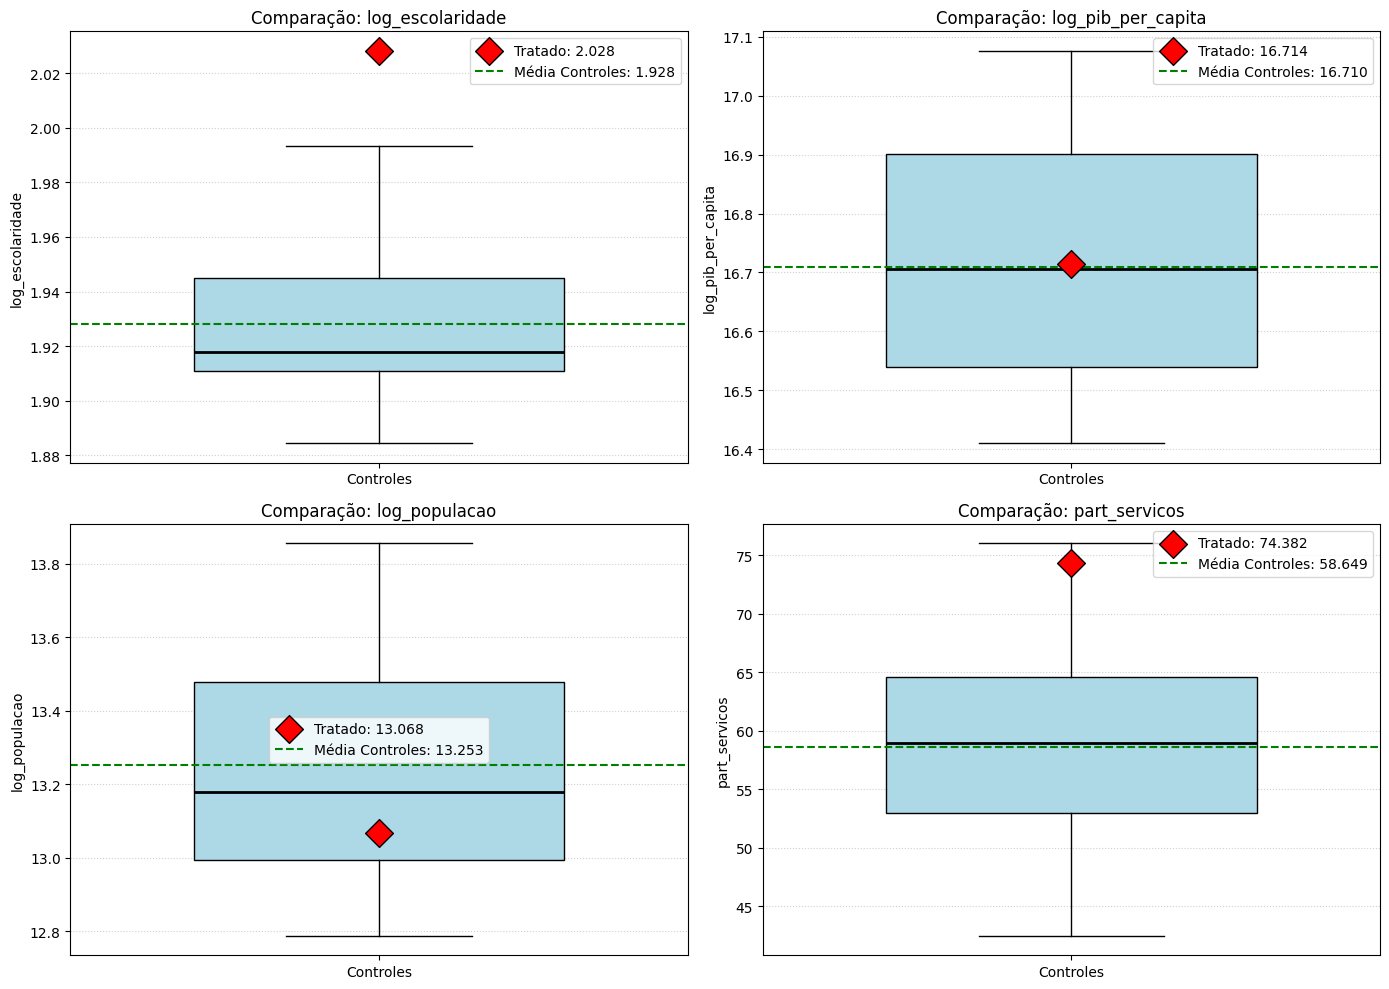

In [70]:
# ================================================================
# Boxplot para cada variável (subplots)
# ================================================================

variaveis = colunas_para_agregar

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    ax = axes[i]
    
    # Dados dos controles
    dados_controle = df_match[df_match["tratamento"] == 0][var].dropna()
    tratado_val = df_match[df_match["tratamento"] == 1][var].iloc[0]
    
    # Boxplot
    bp = ax.boxplot(dados_controle, positions=[1], widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='o', color='blue', alpha=0.5))
    
    # Pontos individuais (opcional, para ver a distribuição)
    # ax.scatter([1]*len(dados_controle), dados_controle, color='blue', alpha=0.3, s=30)
    
    # Ponto do tratado
    ax.scatter(1, tratado_val, color='red', s=200, marker='D', 
               label=f'Tratado: {tratado_val:.3f}', zorder=5, edgecolors='black')
    
    # Linha da média dos controles
    media_controle = dados_controle.mean()
    ax.axhline(y=media_controle, color='green', linestyle='--', 
               label=f'Média Controles: {media_controle:.3f}')
    
    ax.set_ylabel(var)
    ax.set_title(f'Comparação: {var}')
    ax.set_xticks([1])
    ax.set_xticklabels(['Controles'])
    ax.legend(loc='best')
    ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

No blox padronizado abaixo é evidente que há uma diferença significativa entre alguns valores de variáveis de controle

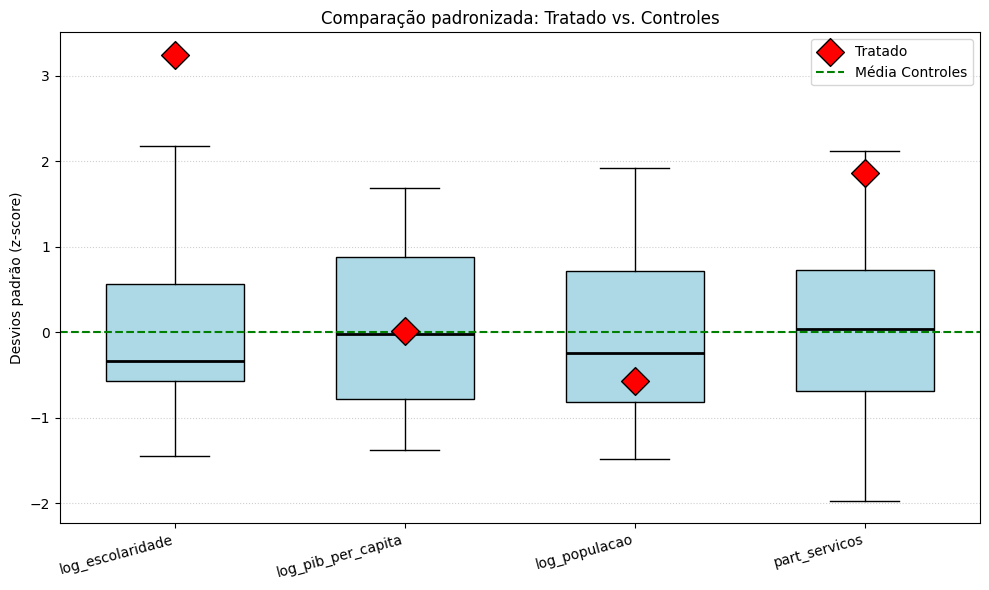

In [71]:
# ================================================================
# Boxplot padronizado (z-score) para todas as variáveis juntas
# ================================================================



# Preparar dados padronizados
dados_padronizados = []
tratado_padronizado = []
nomes_var = []

for var in variaveis:
    # Valores dos controles
    dados = df_match[df_match["tratamento"] == 0][var].dropna()
    if len(dados) == 0:
        continue
    # Padronizar
    dados_z = zscore(dados)
    dados_padronizados.append(dados_z)
    
    # Valor do tratado
    tratado_val = df_match[df_match["tratamento"] == 1][var].iloc[0]
    # Padronizar usando a média e desvio dos controles
    tratado_z = (tratado_val - dados.mean()) / dados.std()
    tratado_padronizado.append(tratado_z)
    
    nomes_var.append(var)

# Criar boxplots lado a lado
plt.figure(figsize=(10, 6))
bp = plt.boxplot(dados_padronizados, positions=range(len(nomes_var)), widths=0.6, patch_artist=True,
                 boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(color='black'),
                 capprops=dict(color='black'),
                 flierprops=dict(marker='o', color='blue', alpha=0.5))

# Pontos do tratado
for i, z in enumerate(tratado_padronizado):
    plt.scatter(i, z, color='red', s=200, marker='D', 
                label='Tratado' if i == 0 else "", zorder=5, edgecolors='black')

# Linha de referência em 0 (média dos controles)
plt.axhline(y=0, color='green', linestyle='--', label='Média Controles')

plt.xticks(range(len(nomes_var)), nomes_var, rotation=15, ha='right')
plt.ylabel('Desvios padrão (z-score)')
plt.title('Comparação padronizada: Tratado vs. Controles')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

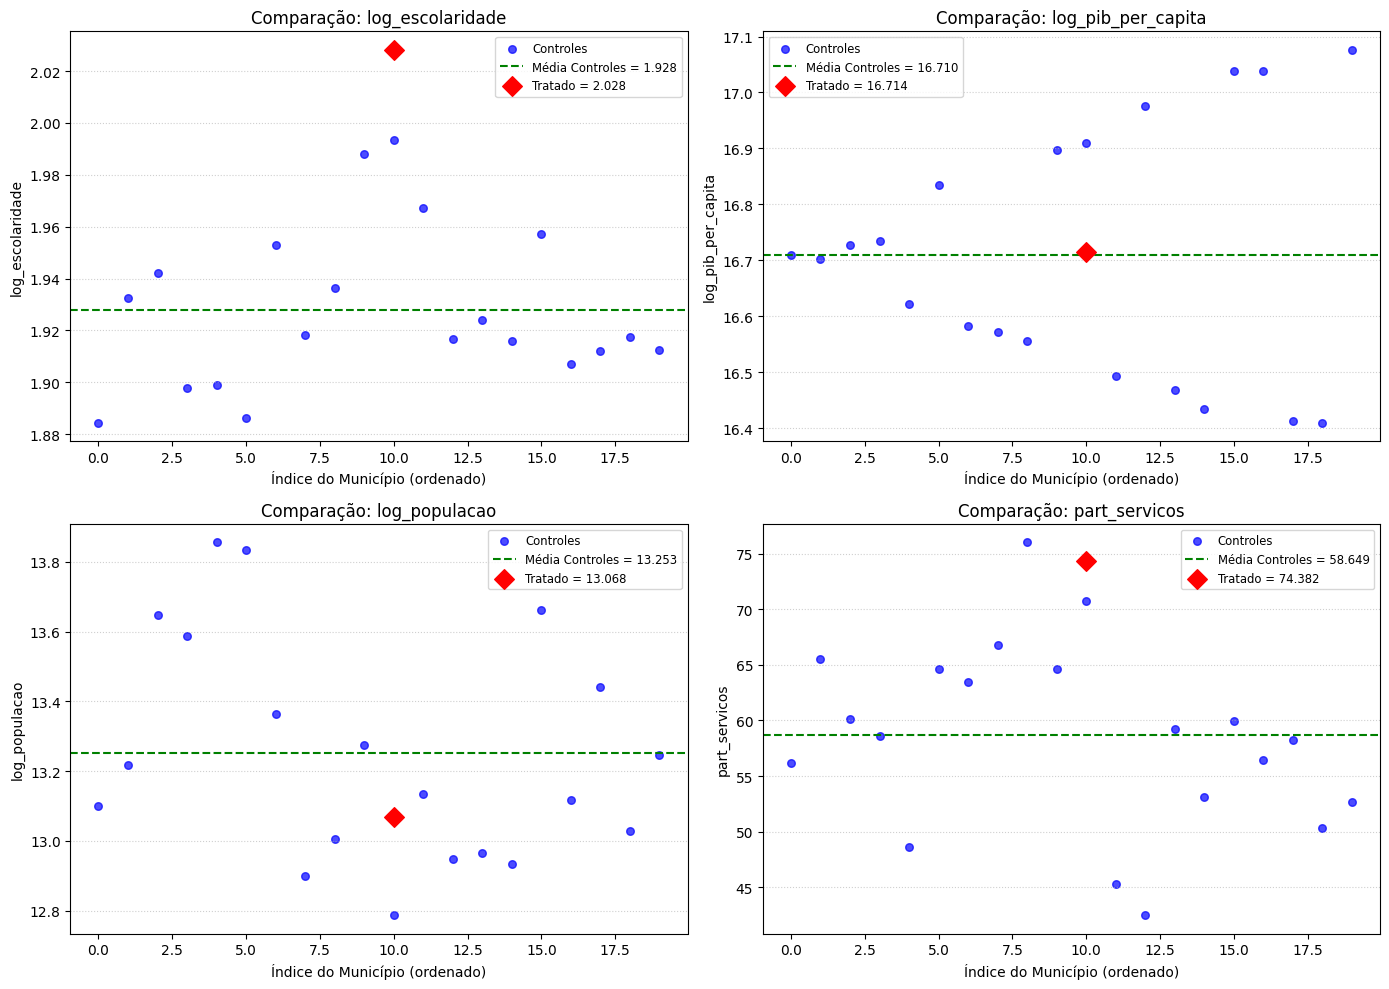

In [72]:
n_vars = len(variaveis)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

# Criar figura com subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
# Se houver apenas um subplot, axes não é um array 2D; ajustar
if n_vars == 1:
    axes = [axes]  # transforma em lista de 1 elemento
else:
    axes = axes.flatten()  # achata para facilitar iteração

# Para cada variável, gerar o gráfico no subplot correspondente
for i, var in enumerate(variaveis):
    ax = axes[i]

    # Extrair valores do tratado (primeiro município tratado) e dos controles
    tratado_val = df_match[df_match["tratamento"] == 1][var].iloc[0]
    controles_vals = df_match[df_match["tratamento"] == 0][var].values
    media_controles = controles_vals.mean()

    # Plotar pontos dos controles
    ax.scatter(range(len(controles_vals)), controles_vals,
               color='blue', label='Controles', s=30, alpha=0.7)

    # Linha horizontal da média dos controles
    ax.axhline(y=media_controles, color='green', linestyle='--',
               label=f'Média Controles = {media_controles:.3f}')

    # Ponto do tratado (destacado)
    ax.scatter(len(controles_vals)/2, tratado_val,
               color='red', s=100, marker='D',
               label=f'Tratado = {tratado_val:.3f}', zorder=5)

    # Personalização
    ax.set_xlabel('Índice do Município (ordenado)')
    ax.set_ylabel(var)
    ax.set_title(f'Comparação: {var}')
    ax.legend(fontsize='small')
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# Esconder subplots não utilizados (caso número ímpar de variáveis)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Abaixo é possível analisar o propensity score do tratado e do grupo de controle

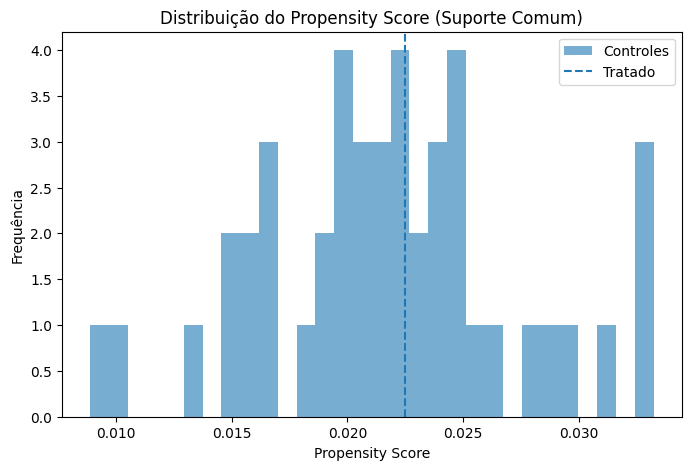

In [73]:

# separar grupos
tratado = df_matching_avg[df_matching_avg["tratamento"] == 1]
controles = df_matching_avg[df_matching_avg["tratamento"] == 0]

plt.figure(figsize=(8,5))

# distribuição controles
plt.hist(controles["propensity_score"], bins=30, alpha=0.6, label="Controles")

# linha do tratado
plt.axvline(tratado["propensity_score"].iloc[0], linestyle="--", label="Tratado")

plt.xlabel("Propensity Score")
plt.ylabel("Frequência")
plt.title("Distribuição do Propensity Score (Suporte Comum)")
plt.legend()

plt.show()